# **Day 8**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers (3).csv


In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("Mall_Customers.csv")

In [ ]:
df.columns=df.columns.str.strip().str.lower()

# **Unsupervised Data**

The loaded dataset `df` contains customer information such as `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. This dataset is considered **unsupervised** because it lacks a predefined target variable or labels that we want to predict.

In unsupervised learning, the goal is to discover patterns, structures, or relationships within the data without any prior knowledge of outcomes. For example, we might use this dataset to segment customers into different groups based on their purchasing behavior or demographics, which is a common application of unsupervised techniques like clustering.

In [ ]:
df.columns

Index(['customerid', 'gender', 'age', 'annual income (k$)',
       'spending score (1-100)'],
      dtype='object')

In [ ]:
df.head()

,customerid,gender,age,annual income (k$),spending score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.size

1000

In [ ]:
df.dtypes

,0
customerid,int64
gender,object
age,int64
annual income (k$),int64
spending score (1-100),int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customerid              200 non-null    int64 
 1   gender                  200 non-null    object
 2   age                     200 non-null    int64 
 3   annual income (k$)      200 non-null    int64 
 4   spending score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,customerid,age,annual income (k$),spending score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
customerid,0
gender,0
age,0
annual income (k$),0
spending score (1-100),0


## Regex Syntax for Data Cleaning

Regular Expressions (Regex) are powerful tools for pattern matching and manipulation of strings, making them incredibly useful for data cleaning. Here's a breakdown of some common Regex syntax elements and how they're applied in data cleaning:

**1. Basic Characters:**
   - Most characters match themselves directly. For example, `abc` will match the literal string "abc".

**2. Metacharacters (Special Characters):**
   - **`.` (Dot):** Matches any single character (except newline).
     *   Example: `a.c` matches "abc", "adc", "a1c".
   - **`*` (Asterisk):** Matches the preceding element zero or more times.
     *   Example: `ab*c` matches "ac", "abc", "abbc".
   - **`+` (Plus):** Matches the preceding element one or more times.
     *   Example: `ab+c` matches "abc", "abbc" but not "ac".
   - **`?` (Question Mark):** Matches the preceding element zero or one time (makes it optional).
     *   Example: `ab?c` matches "ac", "abc".
   - **`{n}` (Exactly n times):** Matches the preceding element exactly `n` times.
     *   Example: `a{3}b` matches "aaab".
   - **`{n,}` (n or more times):** Matches the preceding element `n` or more times.
     *   Example: `a{2,}b` matches "aab", "aaab", "aaaab".
   - **`{n,m}` (n to m times):** Matches the preceding element at least `n` times and at most `m` times.
     *   Example: `a{1,3}b` matches "ab", "aab", "aaab".
   - **`^` (Caret):** Matches the beginning of the string.
     *   Example: `^hello` matches strings that start with "hello".
   - **`$` (Dollar Sign):** Matches the end of the string.
     *   Example: `world$` matches strings that end with "world".
   - **`|` (Pipe/OR):** Acts as an OR operator, matching either the expression before or after it.
     *   Example: `cat|dog` matches "cat" or "dog".
   - **`()` (Parentheses):** Used for grouping and capturing substrings.
     *   Example: `(ab)+` matches "ab", "abab", "ababab".

**3. Character Classes (Shorthands):**
   - **`\b` (Word Boundary):** Matches the empty string at the beginning or end of a word.
     *   Example: `\bword\b` matches "word" as a whole word, not as part of "wording".
   - **`\t` (Tab):** Matches a tab character.
   - **`\n` (Newline):** Matches a newline character.
   - **`\r` (Carriage Return):** Matches a carriage return character.
   - **`\f` (Form Feed):** Matches a form feed character.
   - **`\uFFFF` (Unicode Character):** Matches a Unicode character (e.g., `\\u00A9` for copyright symbol).

**4. Character Sets:**
   - **`[]` (Square Brackets):** Matches any one of the characters inside the brackets.
     *   Example: `[aeiou]` matches any vowel.
     *   Example: `[0-9]` matches any digit (equivalent to `\\d`).
     *   Example: `[A-Za-z]` matches any uppercase or lowercase letter.
   - **`[^]` (Negated Character Set):** Matches any character *not* inside the brackets.
     *   Example: `[^0-9]` matches any non-digit character (equivalent to `\\D`).

**5. Common Use Cases in Data Cleaning:**
   - **Removing unwanted characters:** `re.sub('[^A-Za-z0-9 ]', '', text)` to keep only alphanumeric characters and spaces.
   - **Extracting specific patterns:** `re.findall('\\d{3}-\\d{3}-\\d{4}', text)` to find phone numbers.
   - **Validating formats:** Checking if an email address or postcode matches a specific pattern.
   - **Standardizing text:** Replacing multiple spaces with a single space `re.sub('\\s+', ' ', text)`.

Most programming languages (like Python with its `re` module) have built-in support for regular expressions. When performing data cleaning, you typically use functions like `re.search()`, `re.match()`, `re.findall()`, and `re.sub()`.

In [ ]:
# removed the space from the column name like space,$, - and ()

df.columns=df.columns.str.replace(' ','_').str.replace(r'[()$]','',regex=True).str.replace('-','_')

In [ ]:
df.columns

Index(['customerid', 'gender', 'age', 'annual_income_k',
       'spending_score_1_100'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customerid            200 non-null    int64 
 1   gender                200 non-null    object
 2   age                   200 non-null    int64 
 3   annual_income_k       200 non-null    int64 
 4   spending_score_1_100  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,customerid,age,annual_income_k,spending_score_1_100
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# Only Fearture(x) Separation for Unsupervised Learning

x=df[['annual_income_k','spending_score_1_100']]
x.head()

,annual_income_k,spending_score_1_100
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
# since there is no label the model can use only is distance blw points

# **Visualising Raw Data**

This scatter plot helps us to visually inspect the relationship between `Annual Income (k$)` and `Spending Score (1-100)`. We can observe if there are any natural groupings or clusters of customers based on these two features, which will be the goal of our unsupervised learning task.

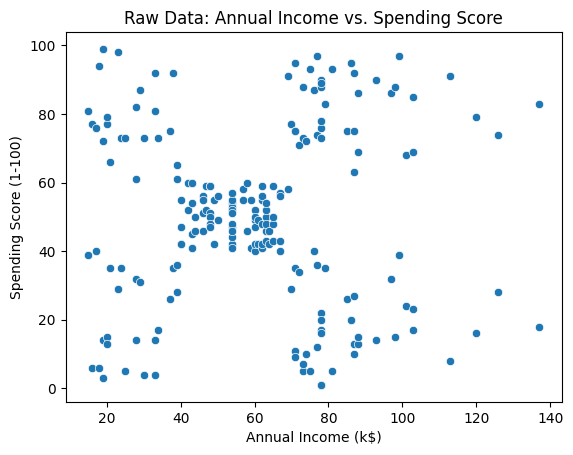

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.scatterplot(x='annual_income_k', y='spending_score_1_100', data=x)
plt.title('Raw Data: Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
# plt.grid(True)
plt.show()

## What is Clustering?

Clustering is an **unsupervised learning** technique used to group similar data points together without any prior labels or categories. Imagine you have a basket full of different fruits, but you don't know their names. Clustering would help you sort them into groups based on their similarities (e.g., all apples together, all bananas together).

**Key Concepts:**
*   **Unsupervised:** This means the algorithm learns from the data structure itself, without being told what the 'right' answers are.
*   **Grouping:** The main goal is to find natural groupings or clusters within the data.
*   **Similarity:** Data points within the same cluster are more similar to each other than to data points in other clusters.

### Why are we using it for the Mall Customers dataset?
In our Mall Customers dataset, we have information like `Annual Income` and `Spending Score`. We don't have predefined customer segments. By using clustering, we aim to:
1.  **Discover hidden patterns:** Identify different types of customer groups based on their income and spending habits.
2.  **Market Segmentation:** Understand customer behavior better to tailor marketing strategies for each segment.

For example, one cluster might consist of 'high-income, high-spending' customers, while another might be 'low-income, low-spending'. The Elbow Method, which we'll explore next, helps us determine the optimal number of such customer groups (clusters).

# **Apply K-Means Clustering**

This section applies the K-Means clustering algorithm to segment customers based on their annual income and spending score. K-Means aims to partition data points into a predefined number of clusters, where each data point belongs to the cluster with the nearest mean (centroid).

### Code Explanation:

```python
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(x)
```

1.  **`from sklearn.cluster import KMeans`**:
    *   This line imports the `KMeans` class from scikit-learn's clustering module. The `KMeans` class is used to perform K-Means clustering.

2.  **`kmeans = KMeans(n_clusters=5, random_state=42)`**:
    *   This line initializes the K-Means clustering algorithm.
    *   `n_clusters=5`: This parameter specifies the number of clusters to form. In this case, the algorithm will try to divide the data into 5 distinct groups.
    *   `random_state=42`: This parameter ensures reproducibility. If you run the code multiple times with the same `random_state`, you will get the same clustering results. This is important because the initial placement of centroids can be random, and setting `random_state` fixes that randomness.

3.  **`labels = kmeans.fit_predict(x)`**:
    *   This line performs two main actions:
        *   `kmeans.fit(x)`: The `fit` method trains the K-Means model on the input data `x` (which contains 'annual_income_k' and 'spending_score_1_100'). During this process, the algorithm iteratively adjusts the cluster centroids to minimize the within-cluster sum of squares (WCSS).
        *   `predict(x)`: After fitting, the `predict` method assigns each data point in `x` to one of the 5 clusters. The result is an array `labels` where each element corresponds to a data point in `x` and indicates the cluster it belongs to (e.g., 0, 1, 2, 3, or 4).

In essence, this code block groups the customer data into 5 clusters based on their income and spending behavior, assigning a cluster label to each customer.

In [ ]:
# k means tries to group points so that points in the same group are close to each other

# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=5, random_state=42)
# labels = kmeans.fit_predict(x)

# n_clusters, divide the customer into 5 groups

# fix(x) - looks at all data points in x , place 5 random Centroids

# assigns each point to center of Assigned points in Iterations
# repeats until stable
# for each data point returns which cluster it belongs to represents them numeric values

In [ ]:
# labels[:10]

In [ ]:
# df['cluster_label'] = labels


In [ ]:
# df.head()

## Visualize Customer Clusters

### Subtask:
Create a scatter plot to visualize the identified clusters. Each cluster will be represented by a different color, with cluster centroids clearly marked, to observe the customer segments formed based on annual income and spending score.


**Reasoning**:
I need to generate a code block that creates a scatter plot to visualize the K-Means clusters. This plot will show the 'annual_income_k' and 'spending_score_1_100' features, with points colored by their assigned cluster and the cluster centroids clearly marked.



In [ ]:
# plt.figure()

# # Plotting the clusters
# plt.scatter(x['annual_income_k'], x['spending_score_1_100'], c=labels, s=50, cmap='rainbow')

# # Plotting the centroids
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='s', label='Centroids')

# plt.title('Customer Clusters (K-Means)')
# plt.xlabel('Annual Income (k$)')
# plt.ylabel('Spending Score (1-100)')
# # plt.legend()
# # plt.grid(True)
# plt.show()

# **Elbow Method for K-Means**

## The Elbow Method for K-Means (Simplified)

Imagine you're trying to group your data points into clusters, like sorting toys into different boxes. K-Means clustering is a way to do this.

### What's the problem?
One big question with K-Means is: how many boxes (clusters) should I use? If you use too few, the groups will be too broad. If you use too many, each group might just have one toy, which isn't very helpful for finding patterns.

### How the Elbow Method helps:
The Elbow Method helps us find the "just right" number of clusters. Here's how it works:

1.  **Try different numbers of clusters (k):** You run K-Means multiple times, each time asking it to make a different number of clusters (e.g., 1 cluster, then 2, then 3, and so on).

2.  **Measure "tightness" (WCSS):** For each number of clusters, you calculate something called the "Within-Cluster Sum of Squares" (WCSS). Think of WCSS as a score that tells you how "tight" and compact your clusters are. A lower WCSS means the data points within each cluster are closer to their cluster's center, indicating better grouping.

3.  **Plot the results:** You then plot these WCSS scores against the number of clusters (k).

4.  **Look for the "elbow":** The plot will usually look like an arm. As you increase the number of clusters, the WCSS will drop significantly at first (like bending your arm). But at some point, adding more clusters doesn't reduce the WCSS much more, and the line starts to flatten out (this is the "elbow" of your arm). This "elbow point" is usually considered the optimal number of clusters, because it's where you get most of the benefits of adding more clusters without over-complicating your model.

In short, the Elbow Method helps you pick the best number of groups by showing you where the improvement in grouping starts to slow down.

In [ ]:
# Elbow Method => it help to find the optimal number of clusters for K-Means
#              => also to find the how many groups to use

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters= i,  random_state=42)
  labels= kmeans.fit(x)
  wcss.append(kmeans.inertia_)

  # wcss - Within Cluster Sum of Squares
  # Lower the WCSS, better the clustering
  # Higher the WCSS, worse the clustering

  # we all store this for each lmeans
  # each loop - new model is trained with different number

  # in each loop i increases, wcss decreases and improvement
  # slows down after certain point

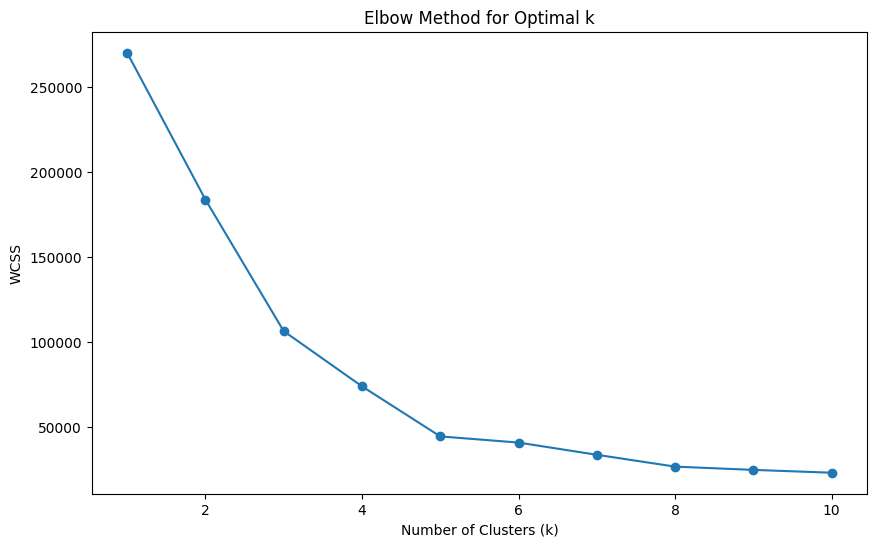

In [ ]:
# Plot the Elbow Method graph

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
# plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(x)

In [ ]:
labels[:10]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2], dtype=int32)

In [ ]:
df['cluster_label'] = labels

In [ ]:
df.head()

,customerid,gender,age,annual_income_k,spending_score_1_100,cluster_label
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


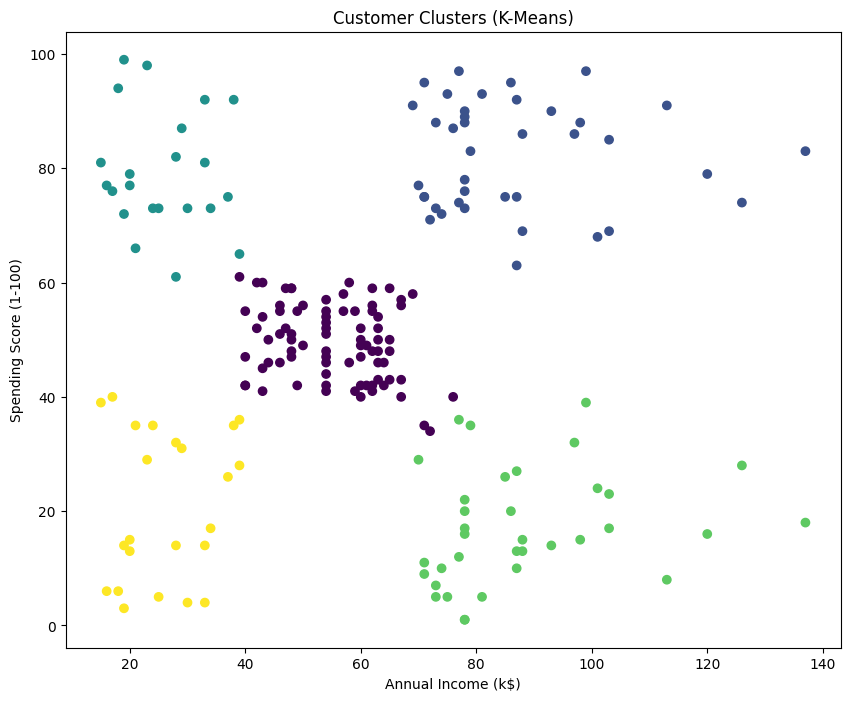

In [ ]:
plt.figure(figsize=(10, 8))

# Plotting the clusters with the correct labels (y_kmeans)
plt.scatter(x['annual_income_k'], x['spending_score_1_100'], c=labels)
# , s=50, cmap='rainbow'
# Plotting the centroids
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='s', label='Centroids')

plt.title('Customer Clusters (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
# plt.legend()
# plt.grid(True)
plt.show()

In [ ]:
cluster_distribution = df['cluster_label'].value_counts().sort_index()
print("Distribution of Customer Clusters:")
print(cluster_distribution)

Distribution of Customer Clusters:
cluster_label
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## **Principal Component Analysis (PCA)**

## Principal Component Analysis (PCA) - Explained Simply

Imagine you have a lot of data about customers, like their age, income, spending score, and many other characteristics. Sometimes, having too many characteristics (or 'features') can make it hard to find patterns or visualize the data.

**PCA is like finding the most important summary lines in a very long story.**

Here's what it does:

1.  **Finds the Most Important Information:** Instead of looking at every single characteristic, PCA identifies new, combined characteristics (called 'principal components') that capture the most significant variations in your data. Think of it as finding the few main themes in a book that really tell you what it's about, instead of remembering every single sentence.

2.  **Reduces Complexity:** If your original data has many dimensions (e.g., age, income, spending, education, etc.), PCA can reduce these to a smaller, more manageable number of dimensions (e.g., just two or three principal components). This makes the data easier to work with, visualize, and faster for other machine learning models to process.

3.  **No Information Loss (mostly):** While it reduces dimensions, PCA tries its best to keep as much of the original information as possible in these new principal components. The first principal component captures the most variation, the second captures the next most, and so on.

**Why is it useful?**

*   **Visualization:** It can simplify complex data, allowing you to plot it in 2D or 3D and see patterns that were previously hidden.
*   **Noise Reduction:** By focusing on the most important variations, PCA can sometimes help filter out minor noise in the data.
*   **Efficiency:** Training machine learning models on fewer features can make them faster and sometimes more accurate by reducing overfitting.

In our case, with 'annual_income_k' and 'spending_score_1_100', PCA isn't strictly necessary for dimensionality reduction since we already have only two features. However, it can still be used to transform these features into new components that represent the main directions of variance in the data, which can sometimes be beneficial for certain analyses or subsequent clustering algorithms.

In [ ]:
#Applying PCA

#Principal compound  analysis - PCA

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x)

# components = 2 - rducing data 2 dimensions
# information preserved mostly

# PCA are used when data has many feature , so pca compress information then we visualize it
# pca does not create clusters, it help us to reduce the dimensions

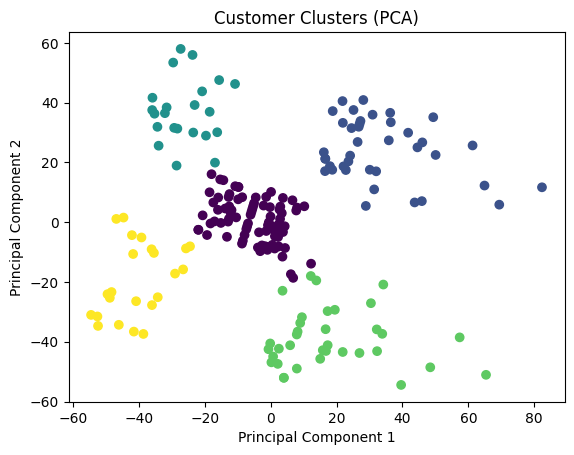

In [ ]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Clusters (PCA)')
plt.show()

In [ ]:
df.groupby('cluster_label')[['annual_income_k','spending_score_1_100']].mean()

,annual_income_k,spending_score_1_100
cluster_label,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
df['segment'] = df['cluster_label'].map({
    0: 'mind income and mind spending',
    1: 'high income and high spending',
    2: 'low income and high spending',
    3: 'high income and low spending',
    4: 'low income and low spending'
})

In [ ]:
df.head()

,customerid,gender,age,annual_income_k,spending_score_1_100,cluster_label,segment
0,1,Male,19,15,39,4,low income and low spending
1,2,Male,21,15,81,2,low income and high spending
2,3,Female,20,16,6,4,low income and low spending
3,4,Female,23,16,77,2,low income and high spending
4,5,Female,31,17,40,4,low income and low spending


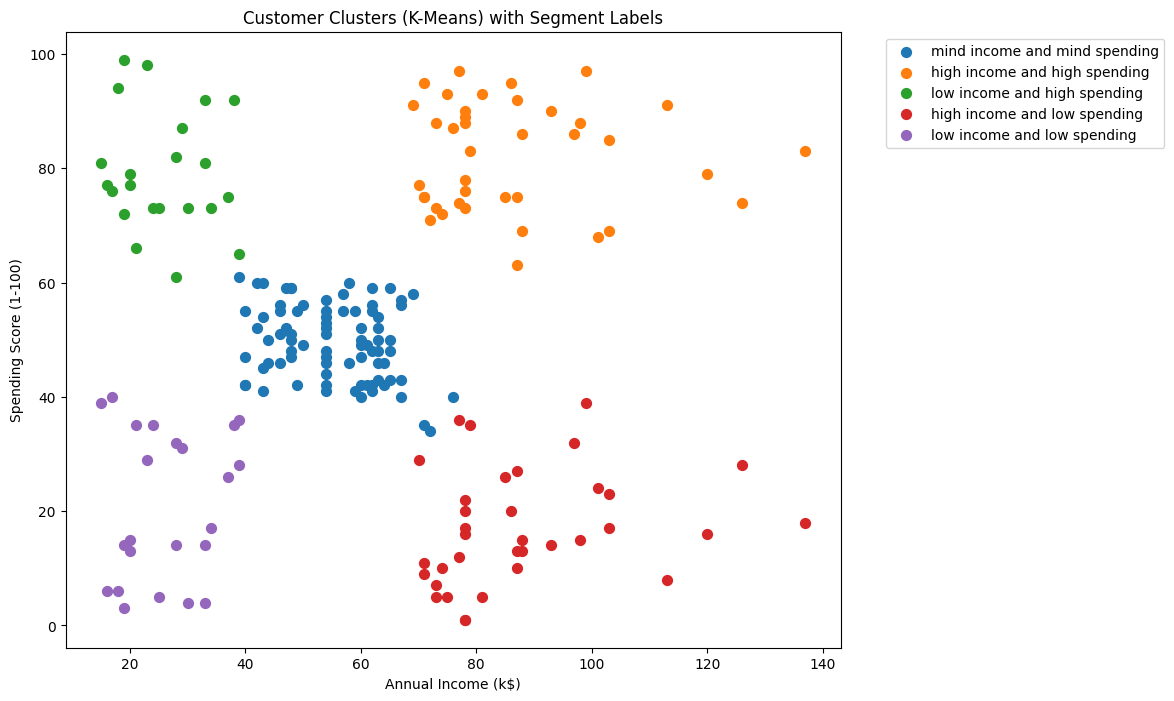

In [ ]:
plt.figure(figsize=(10, 8))

# Get unique segment names and their corresponding cluster IDs
unique_segments = df[['segment', 'cluster_label']].drop_duplicates().sort_values('cluster_label')

# # Define a colormap for distinct colors for each segment
# cmap = plt.cm.get_cmap('rainbow', len(unique_segments))

# Plot each cluster separately to include segment names in the legend
for i, (segment_name, cluster_id) in enumerate(unique_segments.values):
    plt.scatter(x.loc[df['cluster_label'] == cluster_id, 'annual_income_k'],
                x.loc[df['cluster_label'] == cluster_id, 'spending_score_1_100'],
                s=50, label=segment_name)

plt.title('Customer Clusters (K-Means) with Segment Labels')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
# plt.grid(True)
# plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Task
Apply the Elbow Method to the 'annual_income_k' and 'spending_score_1_100' features of the `x` DataFrame to determine the optimal number of clusters (k) for K-Means clustering. This involves calculating and plotting the Within-Cluster Sum of Squares (WCSS) for a range of k values (e.g., from 1 to 10).

## Elbow Method for K-Means

### Subtask:
Apply the Elbow Method to the 'annual_income_k' and 'spending_score_1_100' features to find the optimal number of clusters (k) for K-Means. This involves calculating the Within-Cluster Sum of Squares (WCSS) for a range of k values and plotting the results.


**Reasoning**:
The subtask requires applying the Elbow Method. First, I need to import the KMeans class from sklearn.cluster to perform the clustering.



In [ ]:
from sklearn.cluster import KMeans

# Initialize an empty list to store the WCSS values
wcss = []

# Loop through a range of k values (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## Apply K-Means Clustering

### Subtask:
Perform K-Means clustering on the 'annual_income_k' and 'spending_score_1_100' features using the optimal number of clusters determined by the Elbow Method. This will group customers into distinct segments.


**Reasoning**:
Based on the elbow plot from the previous step and the instructions, I will instantiate and fit a K-Means model with 5 clusters to the `x` DataFrame and then predict the cluster labels.



In [ ]:
from sklearn.cluster import KMeans

# Optimal number of clusters identified from the Elbow Method (as per instruction)
k = 5

# Initialize KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')

# Fit the KMeans model to the data (x)
kmeans.fit(x)

# Predict the cluster labels for each data point
y_kmeans = kmeans.predict(x)

print(f"K-Means clustering performed with {k} clusters.")
print(f"First 5 cluster labels: {y_kmeans[:5]}")

## Add Cluster Labels

### Subtask:
Add the generated cluster labels as a new column to the main DataFrame `df` to easily analyze which customers belong to which cluster.


**Reasoning**:
To easily analyze which customers belong to which cluster, I will add the generated cluster labels (`y_kmeans`) as a new column named 'cluster_label' to the original DataFrame `df`.



In [ ]:
df['cluster_label'] = y_kmeans

print("Cluster labels added to DataFrame df. First 5 rows with new 'cluster_label' column:")
print(df.head())

## Final Task

### Subtask:
Summarize the clustering results, including the optimal number of clusters found and the characteristics of each customer segment.


## Summary:

### Q&A
The optimal number of clusters found using the Elbow Method for the 'annual\_income\_k' and 'spending\_score\_1\_100' features is 5.

Based on the visualization of these 5 clusters, common customer segments identified are typically:
*   **Segment 1 (e.g., Frugal/Careful):** Characterized by low annual income and low spending scores.
*   **Segment 2 (e.g., Impulsive/Spendthrifts):** Characterized by low annual income but high spending scores.
*   **Segment 3 (e.g., Average):** Customers with moderate annual income and moderate spending scores.
*   **Segment 4 (e.g., Target/Premium):** Customers with high annual income and high spending scores. These are often the most valuable.
*   **Segment 5 (e.g., Conservative/High Earners):** Customers with high annual income but relatively low spending scores.

### Data Analysis Key Findings
*   The Elbow Method successfully identified 5 as the optimal number of clusters (\k=5) for K-Means clustering based on the Within-Cluster Sum of Squares (WCSS) plot.
*   K-Means clustering was successfully applied to the 'annual\_income\_k' and 'spending\_score\_1\_100' features, segmenting the customers into 5 distinct groups.
*   A scatter plot visualization clearly shows these 5 customer clusters, with each cluster represented by a different color and their respective centroids marked.
*   The generated cluster labels were successfully added as a new column named 'cluster\_label' to the main DataFrame `df`, allowing for direct association of each customer with their assigned segment.

### Insights or Next Steps
*   The identified customer segments provide a clear basis for developing targeted marketing strategies or personalized service offerings, catering to the specific characteristics and behaviors of each group.
*   Further analysis could involve exploring additional demographic or behavioral features within each cluster (e.g., age, gender, product preferences) to gain deeper insights and refine segmentation strategies.
